## Creating Lo-Fi data for small/large amplitude oscillatory shear (S/LAOS) rheometry
In this notebook, the synthetic generation of Lo-Fi data is introduced based on the given Hi-Fi data. This is a more intricate one as we need to introduce some form of physics to generate the Lo-Fi data.

<img src="../LoFi_LAOS.jpg" alt="MFNN architecture" width="600"/>

First of all, we need to extract the time shift for each S/LAOS test. Note that the given data is in sheets. For each sheet in `Data_HF_SAOS_raw.xlsx`, we need to extract the shifted time, maxietam strain, angular frequency, stress, strain, and strain rate, respectively, by calling the `extractor()` function.


### Importing dependencies

In [31]:
import numpy as np
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from scipy.optimize import curve_fit
from scipy.integrate import odeint
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor  # Import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [32]:
np.set_printoptions(suppress=True)
path = os.getcwd()
files = os.listdir(path)
df = {}
# url = 'https://github.com/procf/RhINNs/raw/main/MFNN/SAOS/Data_HF_SAOS_raw.xlsx'
#Uncomment the below line to run locally
url = pd.ExcelFile(r"C:\Users\alanh\PunLab\mfnn\data\processed\TJC2_23A1.xlsx")

df = pd.read_excel(url, sheet_name=None)
data = [[k,v] for k,v in df.items()]
t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def pos_finder(vector):
    vector = np.array(vector)
    for i in range(len(vector) - 1):
        if vector[i] < 0 and vector[i + 1] >= 0:
            return i + 1
    return -1
    
def extractor(i):
    data[i][1] = data[i][1].dropna()
    print(data[i][0])
    
    #handling the time shift
    ind = pos_finder(data[i][1]['Strain'])
    t0 = data[i][1]['Step time'].iloc[ind]
    ymax = data[i][1]['Stress'].iloc[ind]
    
    #column extraction 
    St = data[i][1]['Strain']
    SR = data[i][1]['Shear rate']
    Time = data[i][1]['Step time']
    w = data[i][1]['Angular frequency']
    G0 = data[i][1]['Oscillation strain']
    Stress = data[i][1]['Stress']
    Time_adj = Time - t0# + 1.*np.pi/w
    Time_adj = Time_adj
    return Time_adj, G0, w, Stress, St, SR


### Extracting $\tau$ and $\eta$
Then, you need to run the following cell for all sheets in `Data_HF_SAOS_raw.xlsx`. For each sheet, we fit a single-mode Maxwell VE model and extract $\tau$ and $\eta$ as a function of $\gamma_0$, $\omega$, and $t$. Note that we are using the `odeint` package, which is an ODE solver. Similar to other ODE solvers, we need initial condition (`y0`), `initial_guess`, and `bounds`. For each sheet, an appropriate `y0` is needed. For this particular sheet, `y0` is 90 Pa.

For this sheet, $\tau$ and $\eta$ are 0.16183 and0.14525, respectively. We do the same thing for all stress curves to obtain the following table:

--- Processing Sheet 0: 0.628rad - 0.00719% ---
0.628rad - 0.00719%


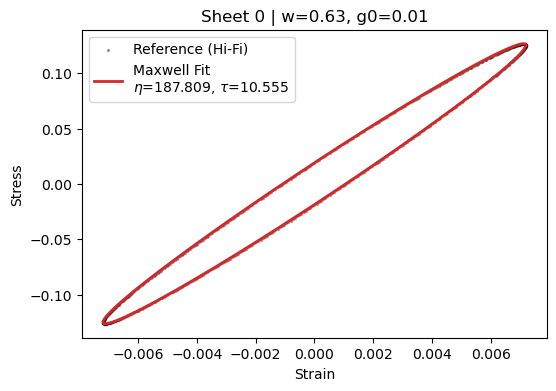

--- Processing Sheet 1: 0.628rad - 0.0255499999999999% ---
0.628rad - 0.0255499999999999%


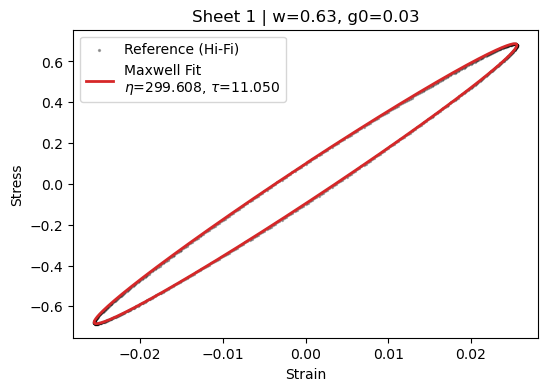

--- Processing Sheet 2: 0.628rad - 0.0872599999999999% ---
0.628rad - 0.0872599999999999%


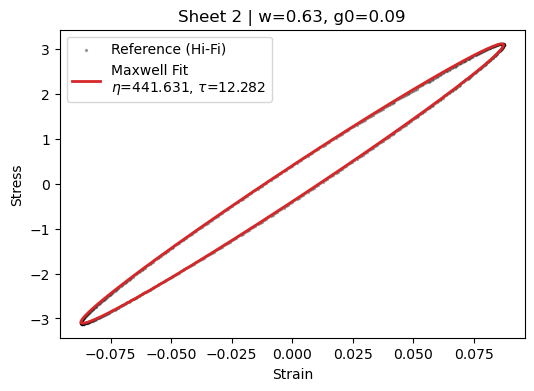

--- Processing Sheet 3: 0.628rad - 0.27413% ---
0.628rad - 0.27413%


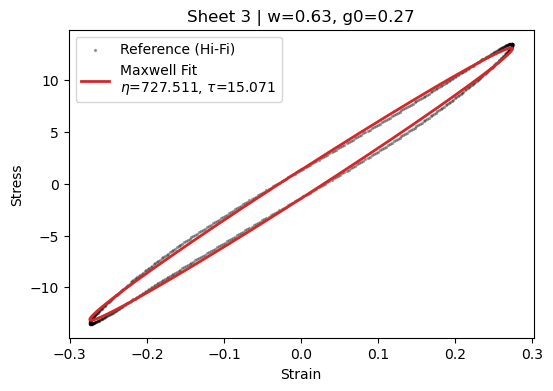

--- Processing Sheet 4: 0.628rad - 0.73965% ---
0.628rad - 0.73965%


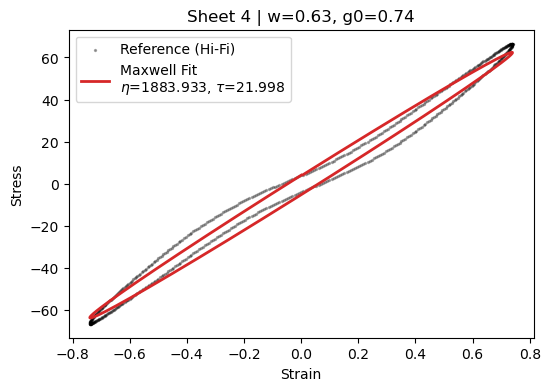

--- Processing Sheet 5: 0.628rad - 2.35937% ---
0.628rad - 2.35937%


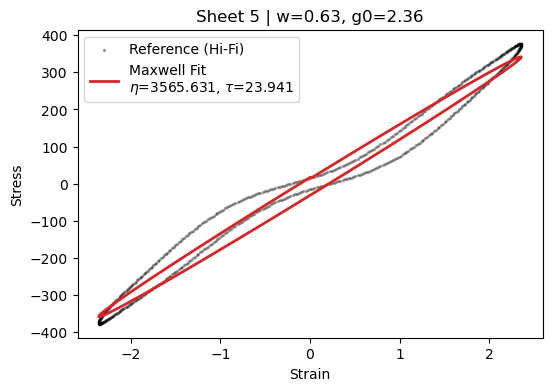

--- Processing Sheet 6: 0.628rad - 18.88231% ---
0.628rad - 18.88231%


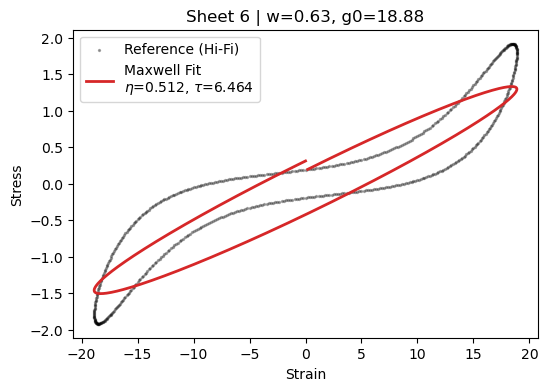

--- Processing Sheet 7: 0.628rad - 31.83309% ---
0.628rad - 31.83309%


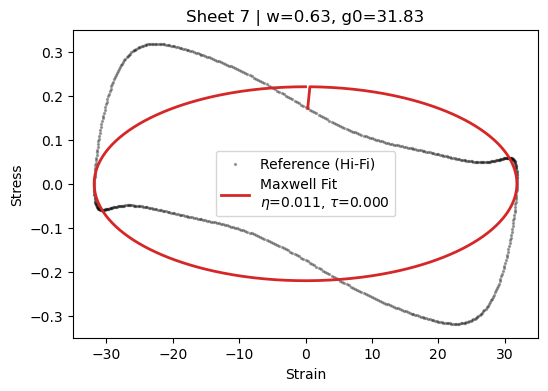

--- Processing Sheet 8: 0.628rad - 100.09074% ---
0.628rad - 100.09074%


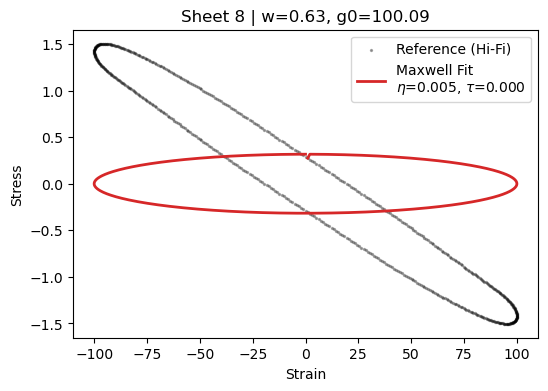


y_fit (eta, tau):
array([[ 187.80916937,   10.55508625],
       [ 299.60837047,   11.04950987],
       [ 441.6312902 ,   12.2817968 ],
       [ 727.51133254,   15.07051102],
       [1883.93300453,   21.99803549],
       [3565.63088964,   23.94088173],
       [   0.51177606,    6.46425195],
       [   0.0110349 ,    0.        ],
       [   0.00504011,    0.        ]])

x_fit (omega, g0):
array([[  0.628  ,   0.00719],
       [  0.628  ,   0.02555],
       [  0.628  ,   0.08726],
       [  0.628  ,   0.27413],
       [  0.628  ,   0.73965],
       [  0.628  ,   2.35937],
       [  0.628  ,  18.88231],
       [  0.628  ,  31.83309],
       [  0.628  , 100.09074]])

y0_fit (initial stress):
array([ 0.02035  ,  0.1062611,  0.4360923,  1.4668446,  4.3725174,
       16.9441914,  0.1964038,  0.1711083,  0.2743191])


In [33]:
# Initialize lists to store the results from all sheets
y_fit_list = []
x_fit_list = []
y0_fit_list = []

# Define the ODE function (relies on global g0, omega, which we update in the loop)
def maxwell_ve(y, t, eta, tau):
    gdot = g0 * omega * np.cos(omega * t * tmax * wmax)
    dydt = (1.0 / tau) * (eta * gdot - y)
    return dydt

def fit_function(t, eta, tau):
    # Solves ODE using the current global y0
    y_pred = odeint(maxwell_ve, y0, t, args=(eta, tau))
    return y_pred[:, 0]

# --- Main Loop over all Data Sheets ---
for i in range(len(data)):
    print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
    # 1. Extract data for this specific sheet
    t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)
    
    # 2. normalization settings (kept from your original code)
    Norm = False
    if Norm:
        tmax = 5.7835
        gmax = 1000.
        wmax = 10.
        smax = 216.73
        t_train, g_train, w_train, s_train = t_train/tmax, g_train/gmax, w_train/wmax, s_train/smax
    else:
        tmax = 1.
        gmax = 1.
        wmax = 1.
        smax = 1.

    # 3. Update Global Variables for the ODE solver
    # We take the unique scalar values for Amplitude (g0) and Frequency (omega)
    # We take the first stress point as the initial condition (y0)
    g0 = np.unique(g_train)[0]
    omega = np.unique(w_train)[0]
    y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
    # Setup fitting vectors
    t = t_train
    y = s_train
    g = g0 * np.sin(omega * t_train * tmax * wmax) # Theoretical strain for plotting
    
    # 4. Perform the Fit
    initial_guess = [0.1, 0.2]  # Generic initial guess
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    
    try:
        fit_params, covariance = curve_fit(fit_function, t, y,
                                           p0=initial_guess,
                                           bounds=bounds,
                                           method='trf',
                                           maxfev=5000)
        eta_fit, tau_fit = fit_params
    except RuntimeError:
        print(f"Fit failed for sheet {i}. Using zeros.")
        eta_fit, tau_fit = 0.0, 0.0

    # 5. Append results to lists
    # y_fit stores [eta, tau]
    y_fit_list.append([eta_fit, tau_fit])
    # x_fit stores [omega, g0]
    x_fit_list.append([omega, g0])
    # y0_fit stores the initial stress
    y0_fit_list.append(y0)

    # 6. Plot the result for visual verification
    y_predicted = fit_function(t, eta_fit, tau_fit)
    
    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.2f}, g0={g0:.2f}")
    plt.scatter(g, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
    plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()

# --- Convert lists to numpy arrays for the next steps ---
y_fit = np.array(y_fit_list)
x_fit = np.array(x_fit_list)
y0_fit = np.array(y0_fit_list)

print("\ny_fit (eta, tau):")
print(repr(y_fit))
print("\nx_fit (omega, g0):")
print(repr(x_fit))
print("\ny0_fit (initial stress):")
print(repr(y0_fit))

In [34]:
# #The entire fitting parameters
# y_fit = np.array([[ 1.3018589 ,  6.88171745],
#        [ 2.81325174, 10.19232574],
#        [ 3.53696276,  9.6563423 ],
#        [ 6.54552896, 13.53587704],
#        [21.35111473, 25.29370299],
#        [50.09332498, 34.29473828]])

# x_fit = np.array([[  0.628319,   0.597749],
#        [  0.628319,   2.06854 ],
#        [  0.628319,   8.00354 ],
#        [  0.628319,  26.537   ],
#        [  0.628319,  75.4325  ],
#        [  0.628319, 357.178   ]])
# y0_fit = np.array([ -0.0186151,   0.100272 ,   1.438    ,   9.25357  ,  55.5056   ,
#        273.898    ])

### Masking Hi-Fi data
Here, and depending on which stress loop we wish to omit from MFNN training, we select from `hf_set`.

In [35]:
hf_set = [0, 1, 2, 4, 5]
y_max = y_fit[hf_set]
x_max = x_fit[hf_set]
y_00 = y0_fit[hf_set]
set1 = {tuple(row) for row in x_fit}
set2 = {tuple(row) for row in x_max}
diff = np.array([list(row) for row in (set1 - set2)])
print('The masked set(s) are:\n', diff)

The masked set(s) are:
 [[  0.628     0.27413]
 [  0.628    31.83309]
 [  0.628   100.09074]
 [  0.628    18.88231]]


### Regression of $\tau$ and $\eta$ on $\gamma_0$ and $\omega$

Here, we have several options to select the regression kernel. The output of this cell is the regressed $\tau$ and $\eta$ values for each kernel.

In [36]:
poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
poly_regressor.fit(x_max, y_max)
poly_predictions = poly_regressor.predict(x_max)
rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf_regressor.fit(x_max, y_max)
rf_predictions = rf_regressor.predict(x_max)
mlp_regressor = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20),
                                                  max_iter=10000,
                                                  random_state=4,
                                                  solver='lbfgs',
                                                 activation='tanh',
                                                 alpha=1e-3))
mlp_regressor.fit(x_max, y_max)
mlp_predictions = mlp_regressor.predict(x_max)

print("Second-Order Polynomial Regression Predictions:")
print(poly_predictions)

print("\nRandom Forest Regression Predictions:")
print(rf_predictions)

print("\nMLP Regression Predictions:")
print(mlp_predictions)

Second-Order Polynomial Regression Predictions:
[[ 223.00001018   10.65029343]
 [ 271.57490409   11.0148534 ]
 [ 432.24758838   12.21010255]
 [1886.3844624    22.01028129]
 [3565.40575917   23.93977947]]

Random Forest Regression Predictions:
[[ 244.59555922   10.88189157]
 [ 294.90519971   11.1043822 ]
 [ 405.31925017   11.96728482]
 [1350.5020954    18.37696087]
 [2861.20599602   22.38120679]]

MLP Regression Predictions:
[[1275.64529426   10.60671077]
 [1275.64529421   10.98793786]
 [1275.64529402   12.29181235]
 [1275.64529241   21.99937495]
 [1275.64529024   23.93905999]]


### Hi-Fi data extraction and sampling
Since we used the raw Hi-Fi data, we need to extract those shifted Hi-Fi data and use them for MFNN training. Also, the given Hi-Fi data was too dense, and we sample every 40 of them.

In [37]:
g0_hf, t_hf, w_hf = np.array([]), np.array([]), np.array([])
g_hf, gdot_hf, s_hf = np.array([]), np.array([]), np.array([])

for i in hf_set:

    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)
    
    g0_hf = np.append(g0_hf, g0_test)
    t_hf = np.append(t_hf, t_test)
    w_hf = np.append(w_hf, w_test)
    
    g_hf = np.append(g_hf, st_test)
    gdot_hf = np.append(gdot_hf, sr_test)
    s_hf = np.append(s_hf, s_test)

    
    
sampled_indices = np.arange(0, len(t_hf), 40)
t_hf_sampled = t_hf[sampled_indices]
g0_hf_sampled = g0_hf[sampled_indices]
w_hf_sampled = w_hf[sampled_indices]
g_hf_sampled = g_hf[sampled_indices]
gdot_hf_sampled = gdot_hf[sampled_indices]
s_hf_sampled = s_hf[sampled_indices]

0.628rad - 0.00719%
0.628rad - 0.0255499999999999%
0.628rad - 0.0872599999999999%
0.628rad - 0.73965%
0.628rad - 2.35937%


Almost there. Now, for each set in `lf_set`, which is essentially all the loops, we call the `fit_function()` function, which predicts the linear VE stress response as a function of `t_pred`, `eta_pred`, and `tau_pred`. We then append every variable to an empty vector, and call that our Lo-Fi data. Keeping an eye on the top image as reference can also help. :)

0.628rad - 0.00719%


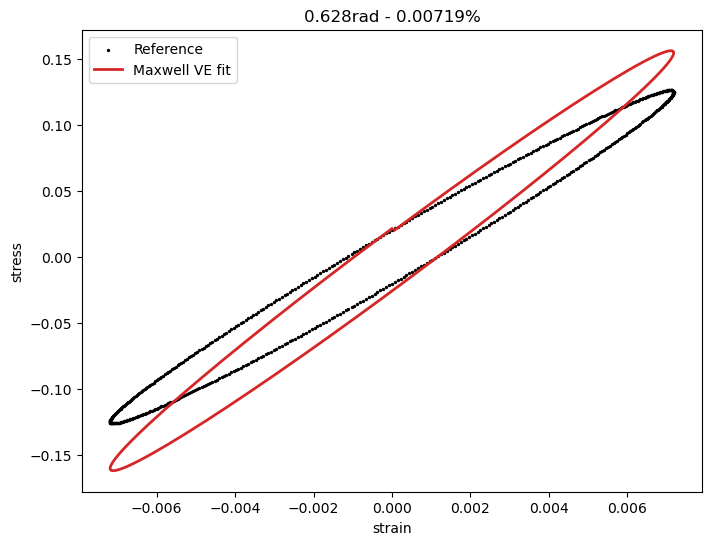

0.628rad - 0.0255499999999999%


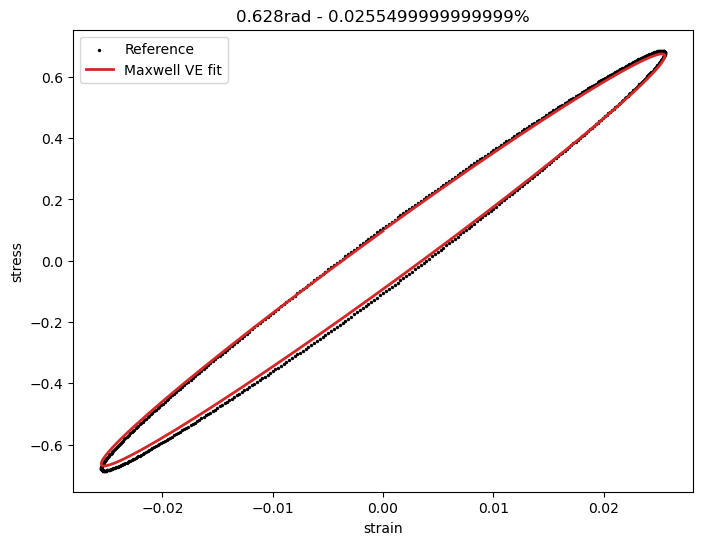

0.628rad - 0.0872599999999999%


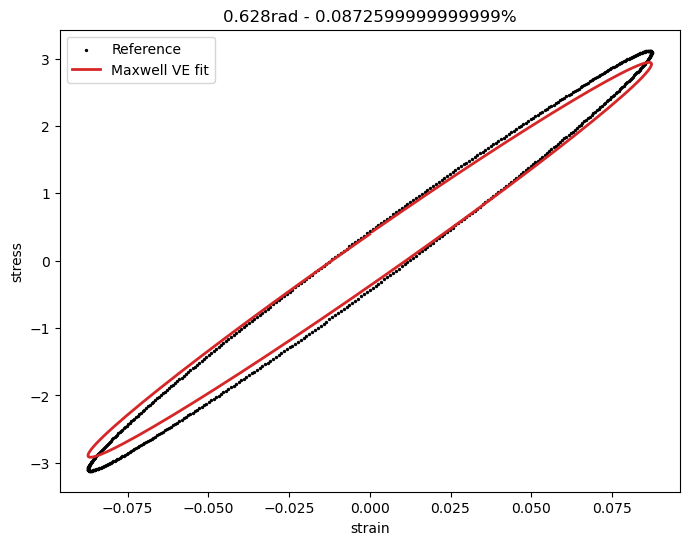

0.628rad - 0.27413%


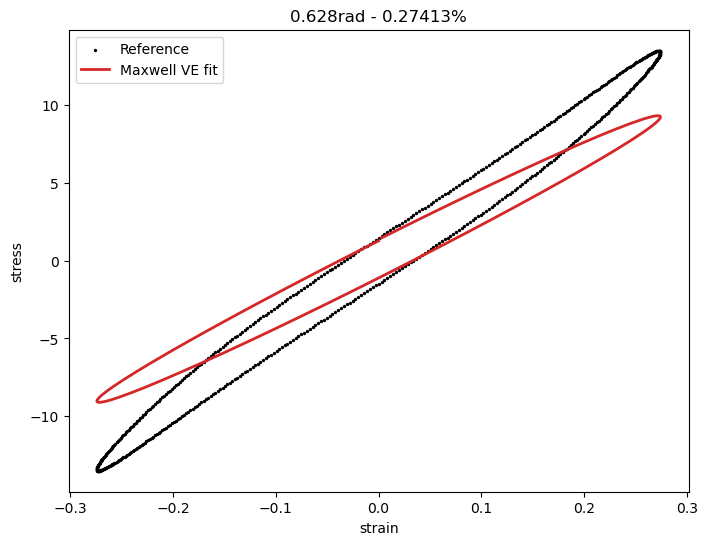

0.628rad - 0.73965%


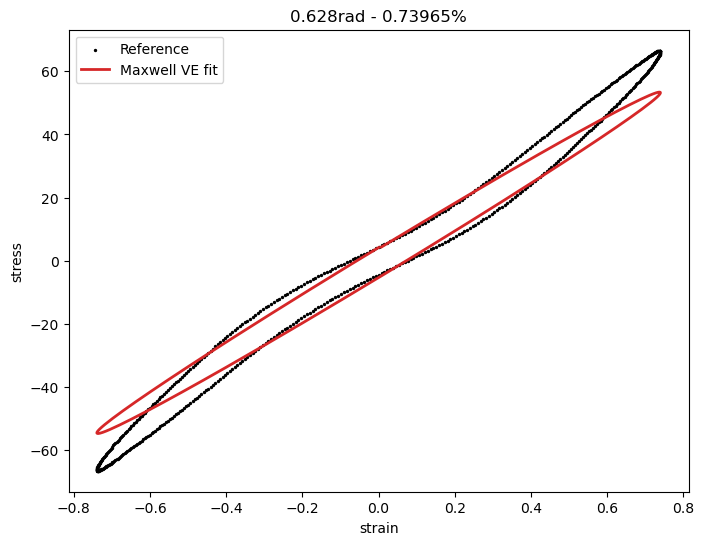

0.628rad - 2.35937%


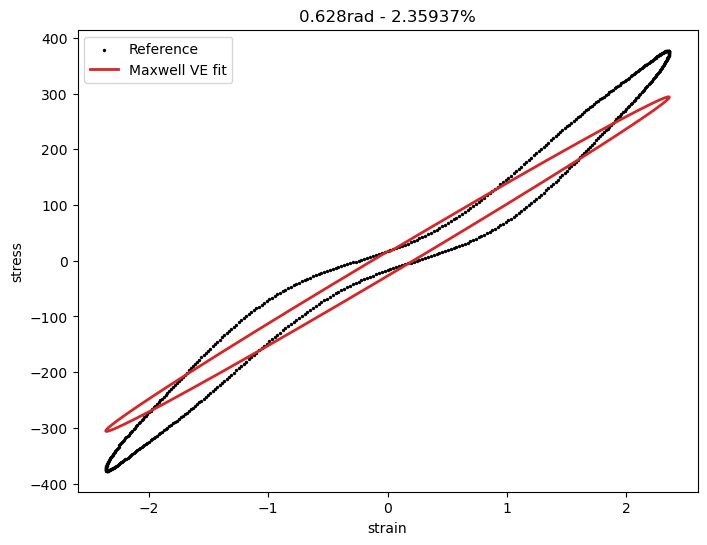

In [38]:
# %%
y000 = y0_fit
g00 = x_fit[:,1]
omega0 = x_fit[:,0]
lf_set = [0, 1, 2, 3, 4, 5]
N_exp = int(10.*len(s_hf_sampled)/len(lf_set))

g0_exp, t_exp, w_exp = np.array([]), np.array([]), np.array([])
g_exp, gdot_exp, s_exp = np.array([]), np.array([]), np.array([])

for i in lf_set:

    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)

    omega = omega0[i]
    g0 = g00[i]
    y0 = y000[i]
    
    x_pred = np.reshape([omega, g0], (1,-1))
    eta_pred, tau_pred = rf_regressor.predict(x_pred)[0]

    t_pred = np.linspace(min(t_test), max(t_test), N_exp)
    y_pred = fit_function(t_pred, eta_pred, tau_pred)
    
    g_pred = g0 * np.sin(omega * t_pred)
    gdot_pred = g0*omega*np.cos(omega * t_pred)/100.
    
    #LF generation
    g0_exp = np.append(g0_exp, g0*np.ones(N_exp))
    t_exp = np.append(t_exp, t_pred)
    w_exp = np.append(w_exp, omega*np.ones(N_exp))
    
    g_exp = np.append(g_exp, g_pred)
    gdot_exp = np.append(gdot_exp, gdot_pred)
    s_exp = np.append(s_exp, y_pred)

    plt.figure(figsize=(8, 6))
    plt.title(data[i][0]) # Added title here
    plt.scatter(st_test * 100, s_test, label='Reference', s=2, color='k')
    plt.plot(g_pred, y_pred, label='Maxwell VE fit', color='tab:red', lw=2)
    plt.xlabel('strain')
    plt.ylabel('stress')
    plt.legend()
    plt.show()

### Exporting the Lo-Fi and Hi-Fi SAOS data
As mentioned above, and due to the time shift, the Hi-Fi data is also generated here based on the raw Hi-Fi data.

In [39]:
df_LF_raw = np.column_stack([g0_exp, t_exp, w_exp, g_exp, gdot_exp, s_exp])
df_LF = pd.DataFrame(df_LF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_LF.to_excel("Data_LF_SAOS.xlsx", index=False)

In [40]:
df_HF_raw = np.column_stack([g0_hf_sampled, t_hf_sampled,
                             w_hf_sampled, g_hf_sampled,
                             gdot_hf_sampled, s_hf_sampled])
df_HF = pd.DataFrame(df_HF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_HF.to_excel("Data_HF_SAOS.xlsx", index=False)